# Graphs for Demand Exercise

NOTE: The scripts below requires python and an installation of the pybalmorel module. This module is very new, so be critical. Feel free to post issues [here](https://github.com/Mathias157/pybalmorel/issues)

**Installation:**

Open a terminal, activate your virtual environment and write:

`pip install pybalmorel`

## Loading Results

In [3]:
!pip install pybalmorel

In [4]:
import pybalmorel 
import matplotlib.pyplot as plt

In [7]:
from pybalmorel import MainResults
from pybalmorel.formatting import balmorel_colours

# Write the exact names of the scenarios and the path (or paths) that they aC:\\Users\\Bruger\\OneDrive\\Documents\\Master\\4. June 2026\\Large scale energy system analysis\\Excersice\\Lecture_2\\BalmorelSimpleModel_LP\\BalmorelSimpleModel_LP\\Balmorel\\Lecture_2_Ex_0\\model\\re in
res = MainResults(files=["1.gdx", "2.gdx", "3.gdx", "4.gdx", "Base.gdx", "2025.gdx"
                                                  ], 
                  paths='C:\\Users\\inesm\\Documents\\GAMS\\BalmorelSimpleModel_LP\\BalmorelSimpleModel_LP\\Balmorel\\LSESAub\\0_results_for_python_noDECOM')

Loading C:\Users\inesm\Documents\GAMS\BalmorelSimpleModel_LP\BalmorelSimpleModel_LP\Balmorel\LSESAub\0_results_for_python_noDECOM\1.gdx
Loading C:\Users\inesm\Documents\GAMS\BalmorelSimpleModel_LP\BalmorelSimpleModel_LP\Balmorel\LSESAub\0_results_for_python_noDECOM\2.gdx
Loading C:\Users\inesm\Documents\GAMS\BalmorelSimpleModel_LP\BalmorelSimpleModel_LP\Balmorel\LSESAub\0_results_for_python_noDECOM\3.gdx
Loading C:\Users\inesm\Documents\GAMS\BalmorelSimpleModel_LP\BalmorelSimpleModel_LP\Balmorel\LSESAub\0_results_for_python_noDECOM\4.gdx
Loading C:\Users\inesm\Documents\GAMS\BalmorelSimpleModel_LP\BalmorelSimpleModel_LP\Balmorel\LSESAub\0_results_for_python_noDECOM\Base.gdx
Loading C:\Users\inesm\Documents\GAMS\BalmorelSimpleModel_LP\BalmorelSimpleModel_LP\Balmorel\LSESAub\0_results_for_python_noDECOM\2025.gdx


## Plotting CO2 emissions Validation

Raw result columns: ['Scenario', 'Y', 'C', 'RRR', 'AAA', 'G', 'FFF', 'TECH_TYPE', 'UNITS', 'Value']
Unique values in C: ['DENMARK', 'NORWAY']
Pivot columns after aggregation (kton): ['DENMARK', 'NORWAY']
C          DENMARK    NORWAY
Scenario                    
1         3.151366  0.000612
2         3.222512  0.000436
2025      5.126638  0.000964
3         3.573816  0.000460
4         3.546214  0.000460


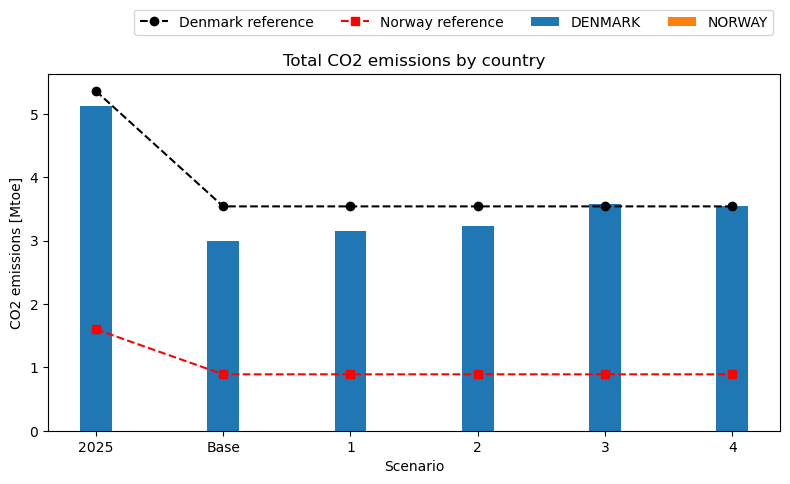

In [28]:
import pandas as pd
import numpy as np

obj_emi = res.get_result('EMI_YCRAG')

# Print raw columns and values to verify that Norway is present
print('Raw result columns:', obj_emi.columns.tolist())
print('Unique values in C:', sorted(obj_emi['C'].dropna().unique().tolist()))

# Aggregate by scenario and region/country label in C (values are in kton)
obj_emi = obj_emi.pivot_table(
    index='Scenario',
    columns='C',
    values='Value',
    aggfunc='sum',
    fill_value=0
)

# Convert from kton -> Mt (1 kton = 0.001 Mt)
obj_emi_mton = obj_emi / 1000.0
print('Pivot columns after aggregation (kton):', obj_emi.columns.tolist())
print(obj_emi_mton.head())

# Reorder scenarios and ensure no missing values
obj_emi_mton = obj_emi_mton.reindex(['2025', 'Base', '1', '2', '3', '4']).fillna(0)

# Hardcoded reference values (in Mt) for comparison
# Replace these numbers if your references are in other units
denmark_ref = {'2025': 5.36, 'Base': 3.54, '1': 3.54, '2': 3.54, '3': 3.54, '4': 3.54}  # Denmark: 2025 and 2030(Base)
norway_ref = {'2025': 1.60, 'Base': 0.89, '1': 0.89, '2': 0.89, '3': 0.89, '4': 0.89}   # Norway: 2025 and 2030(Base)

# Build series aligned with the DataFrame index
den_series = pd.Series(denmark_ref).reindex(obj_emi_mton.index)
nor_series = pd.Series(norway_ref).reindex(obj_emi_mton.index)

# Plot stacked bars (Mt) with thinner columns
ax = obj_emi_mton.plot(kind='bar', stacked=True, ylabel='CO2 emissions [Mtoe]', grid=False, rot=0, figsize=(8,5), width=0.25)
ax.set_title('Total CO2 emissions by country')

# Overlay hardcoded reference points/lines
x = np.arange(len(obj_emi_mton.index))
ax.plot(x, den_series.values, marker='o', linestyle='--', color='black', label='Denmark reference')
ax.plot(x, nor_series.values, marker='s', linestyle='--', color='red', label='Norway reference')

# Adjust legend and layout
ax.legend(bbox_to_anchor=(1, 1.2), ncols=4)
plt.tight_layout()
plt.show()


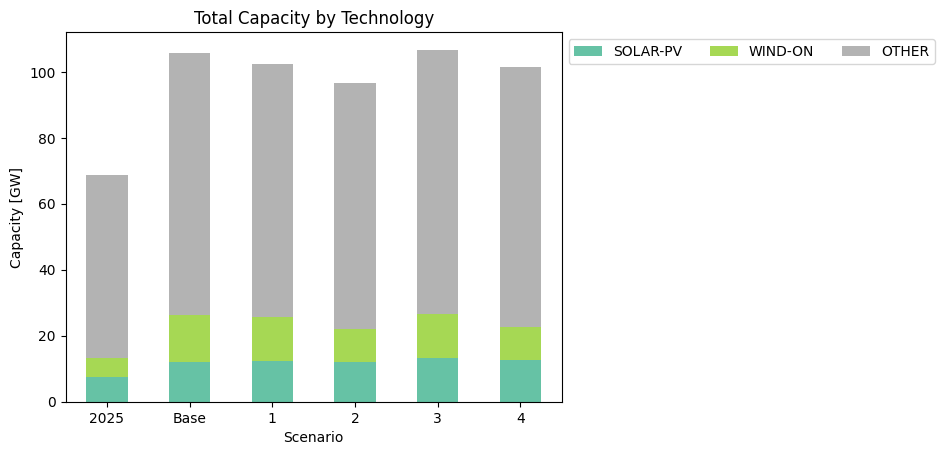

In [ ]:
obj = res.get_result('G_CAP_YCRAF')

# Aggregate
obj = obj.pivot_table(index='Scenario', 
                      columns=['Technology'],  
                      values='Value',
                      aggfunc='sum')

# Define the target technologies (Note: matching 'HYDRO-RESERVOIRS' to your original image legend)
target_techs = ['SOLAR-PV', 'WIND-ON']

# 1. Sum up all other columns into 'OTHER'
obj['OTHER'] = obj.loc[:, ~obj.columns.isin(target_techs)].sum(axis=1)

# 2. Keep ONLY the target technologies + 'OTHER'
obj = obj[target_techs + ['OTHER']]

# Make the order of scenarios correct
obj = obj.reindex(['2025', 'Base', '1', '2', '3', '4'])

# Choose a colormap like 'viridis', 'Set2', 'tab10', 'Pastel1', or 'coolwarm'
cmap = plt.colormaps['Set2'] 
num_colors = len(obj.columns)
color_list = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Plot using the color list
ax = obj.plot(kind='bar', stacked=True, ylabel='Capacity [GW]', rot=0, 
              color=color_list) 
ax.set_title('Total Capacity by Technology')
ax.legend(bbox_to_anchor=(1, 1), ncols=3)

In [ ]:
print(obj)

Technology   SOLAR-PV    WIND-ON      OTHER
Scenario                                   
2025         7.492306   5.674378  55.439813
Base        12.076362  14.344724  79.356386
1           12.352468  13.279492  76.785829
2           12.023955  10.079492  74.460728
3           13.194042  13.279492  80.222234
4           12.647621  10.079492  78.725189


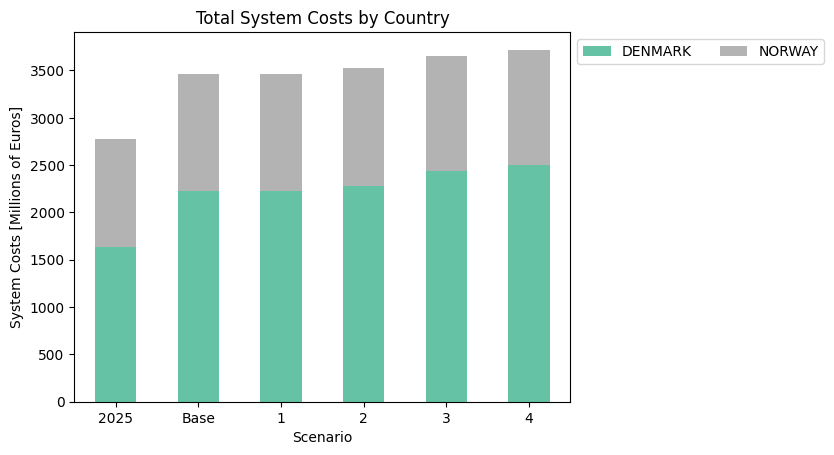

In [ ]:
obj = res.get_result('OBJ_YCR')

# Aggregate
obj = obj.pivot_table(index='Scenario', 
                columns=['Country'],  
                values='Value',
                aggfunc='sum')

# Make the order of scenarios correct
obj = obj.reindex(['2025', 'Base', '1', '2', '3', '4'])

# Choose a colormap like 'viridis', 'Set2', 'tab10', 'Pastel1', or 'coolwarm'
cmap = plt.colormaps['Set2'] 
num_colors = len(obj.columns)
color_list = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Plot using the color list
ax = obj.plot(kind='bar', stacked=True, ylabel='System Costs [Millions of Euros]', rot=0, 
              color=color_list) 
ax.set_title('Total System Costs by Country')
ax.legend(bbox_to_anchor=(1, 1), ncols=4)

In [ ]:
print(obj)

Country       DENMARK       NORWAY
Scenario                          
2025      1630.816499  1146.036438
Base      2226.707589  1234.378753
1         2228.947309  1237.080814
2         2281.717996  1242.212013
3         2438.606273  1218.931855
4         2496.506541  1223.034245


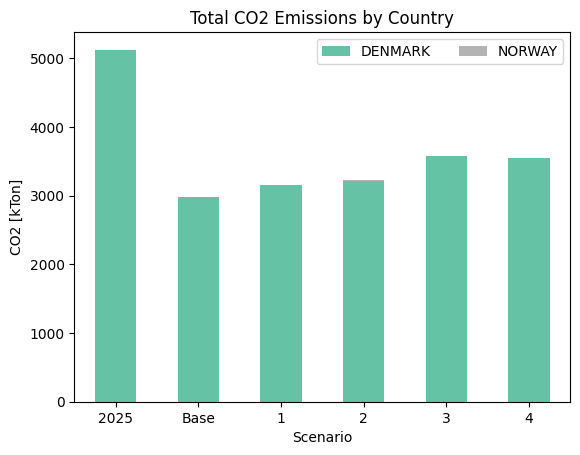

In [ ]:
obj = res.get_result('EMI_YCRAG')

# Aggregate
obj = obj.pivot_table(index='Scenario', 
                      columns=['C'],  
                      values='Value',
                      aggfunc='sum')

# Make the order of scenarios correct
obj = obj.reindex(['2025', 'Base', '1', '2', '3', '4'])

# Choose a colormap like 'viridis', 'Set2', 'tab10', 'Pastel1', or 'coolwarm'
cmap = plt.colormaps['Set2'] 
num_colors = len(obj.columns)
color_list = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Plot using the color list
ax = obj.plot(kind='bar', stacked=True, ylabel='CO2 [kTon]', rot=0, 
              color=color_list) 
ax.set_title('Total CO2 Emissions by Country')
ax.legend(bbox_to_anchor=(1, 1), ncols=4)

In [ ]:
print(obj)

C             DENMARK    NORWAY
Scenario                       
2025      5126.638367  0.963502
Base      2986.489179  0.416647
1         3151.365529  0.611583
2         3222.512282  0.435882
3         3573.815950  0.459683
4         3546.213900  0.459683


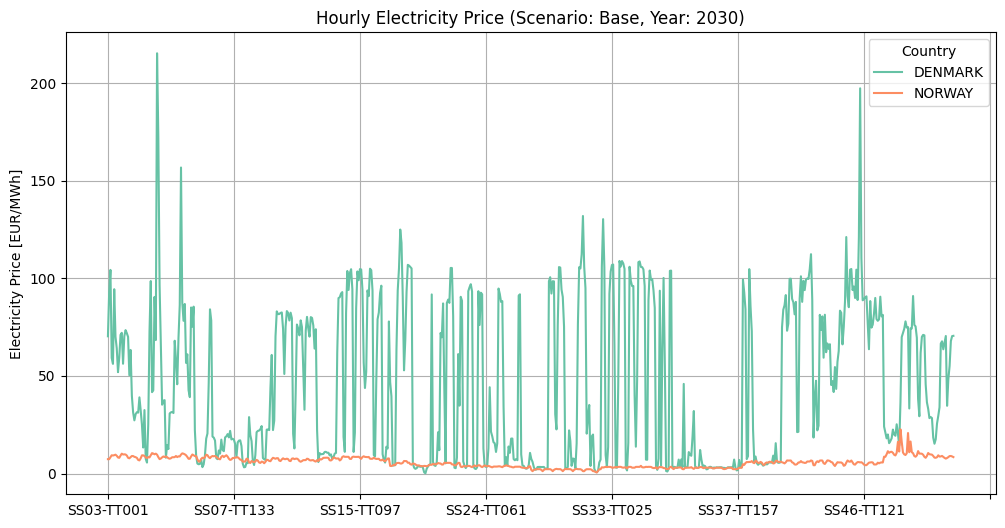

In [ ]:
# 1. Pull raw Balmorel GDX results
obj = res.get_result('EL_PRICE_YCRST')

# METHOD B: Remove any row where the price is greater than 1000
obj = obj[obj['Value'] <= 300]

# 3. Pivot with Time dimensions as rows, and Countries as columns
hourly_prices = obj.pivot_table(
    index=['Season', 'Time'],  # This preserves the chronological time order
    columns=['Country'],  
    values='Value',
    aggfunc='mean'             # Use mean instead of sum in case of duplicate entries
)

# 4. Optional: Flatten the MultiIndex so pandas can plot it sequentially on the x-axis
hourly_prices.index = [f"S{s}-T{t}" for s, t in hourly_prices.index]

# 5. Plot the profile
cmap = plt.colormaps['Set2']
ax = hourly_prices.plot(kind='line', ylabel='Electricity Price [EUR/MWh]', color=cmap.colors, figsize=(12, 6))
ax.set_title('Hourly Electricity Price (Scenario: Base, Year: 2030)')
plt.grid(True)

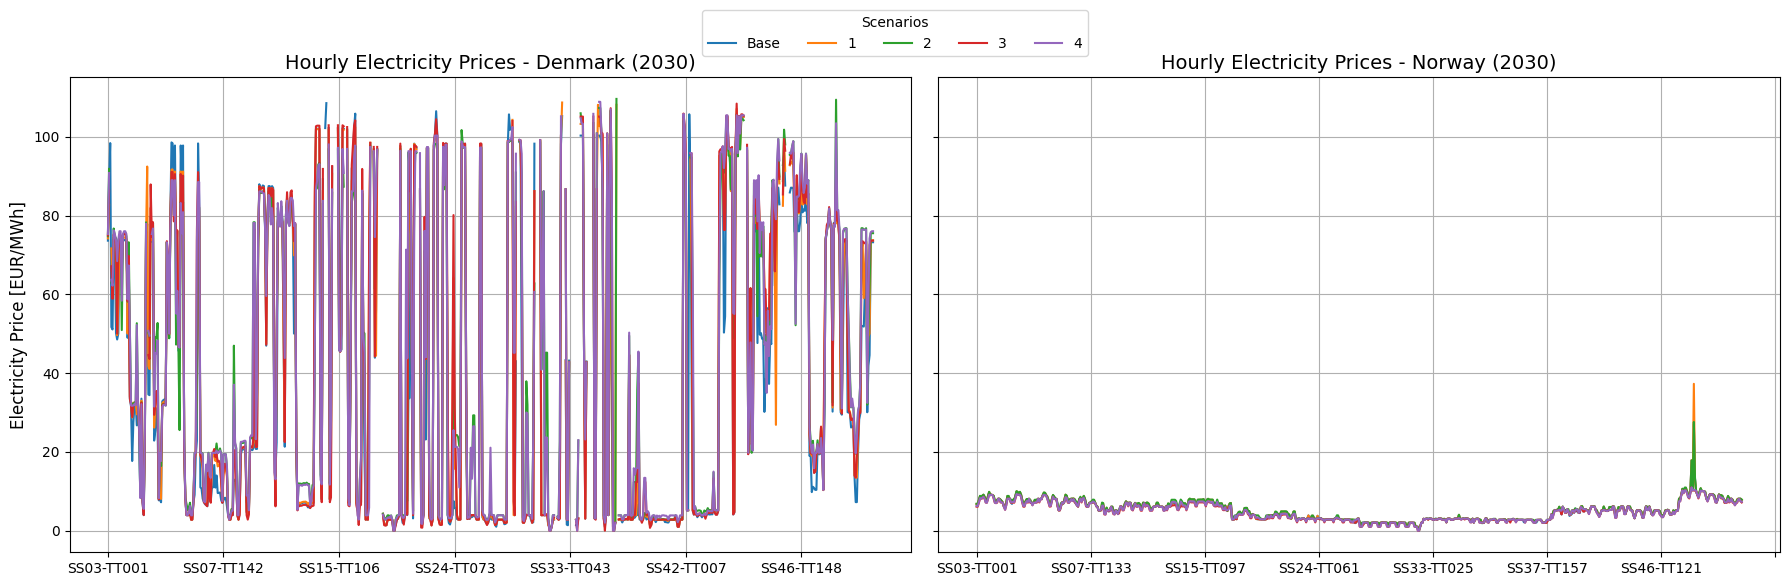

In [ ]:
# 1. Pull raw Balmorel GDX results
obj = res.get_result('EL_PRICE_YCRST')

# 2. Basic cleaning: Filter for your target year and clean up extreme price spikes
obj = obj[obj['Value'] <= 110]

# --- Setup the two side-by-side plots ---
fig, (ax_dk, ax_nor) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
cmap = plt.colormaps['tab10']

# Define custom ordered list for scenario lines
scenario_order = ['Base', '1', '2', '3', '4']

# ==========================================
# PLOT 1: DENMARK
# ==========================================
# (Note: Check if your GDX uses 'DENMARK' or 'DK' based on your previous print)
obj_dk = obj[obj['Country'] == 'DENMARK']

prices_dk = obj_dk.pivot_table(
    index=['Season', 'Time'], 
    columns=['Scenario'], 
    values='Value', 
    aggfunc='mean'
).reindex(columns=scenario_order)

prices_dk.index = [f"S{s}-T{t}" for s, t in prices_dk.index]

prices_dk.plot(kind='line', ax=ax_dk, color=cmap.colors)
ax_dk.set_title('Hourly Electricity Prices - Denmark (2030)', fontsize=14)
ax_dk.set_ylabel('Electricity Price [EUR/MWh]', fontsize=12)
ax_dk.grid(True)
ax_dk.get_legend().remove() # Remove temporary legend to clean up spacing

# ==========================================
# PLOT 2: NORWAY
# ==========================================
# (Note: Check if your GDX uses 'NORWAY' or 'NO')
obj_nor = obj[obj['Country'] == 'NORWAY']

prices_nor = obj_nor.pivot_table(
    index=['Season', 'Time'], 
    columns=['Scenario'], 
    values='Value', 
    aggfunc='mean'
).reindex(columns=scenario_order)

prices_nor.index = [f"S{s}-T{t}" for s, t in prices_nor.index]

prices_nor.plot(kind='line', ax=ax_nor, color=cmap.colors)
ax_nor.set_title('Hourly Electricity Prices - Norway (2030)', fontsize=14)
ax_nor.grid(True)
ax_nor.get_legend().remove()

# ==========================================
# SHARED LEGEND
# ==========================================
# Place a single clean legend for the scenarios at the top or side
handles, labels = ax_dk.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncols=6, title="Scenarios")

plt.tight_layout(rect=[0, 0, 1, 0.92]) # Make room for the header legend
plt.show()

## Plotting Profiles

(0.0, 42.0)

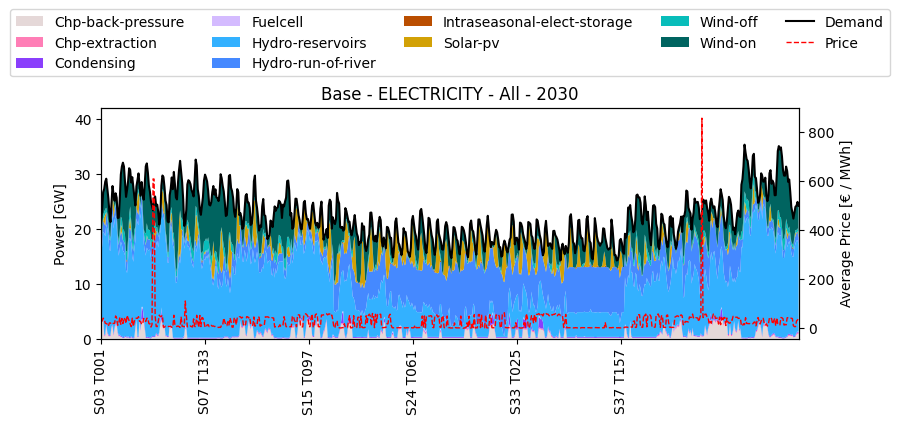

In [ ]:
fig, ax = res.plot_profile('Electricity', 2030, scenario='Base')
ax.set_ylim([0, 42])




In [ ]:
fig, ax = res.plot_profile('Heat', 2050, scenario='base')
ax.set_ylim([0, 42])
fig, ax = res.plot_profile('Heat', 2050, scenario='netzero')
ax.set_ylim([0, 42])
fig, ax = res.plot_profile('Heat', 2050, scenario='netnegative')
ax.set_ylim([0, 42])

KeyError: 'base'

(0.0, 42.0)

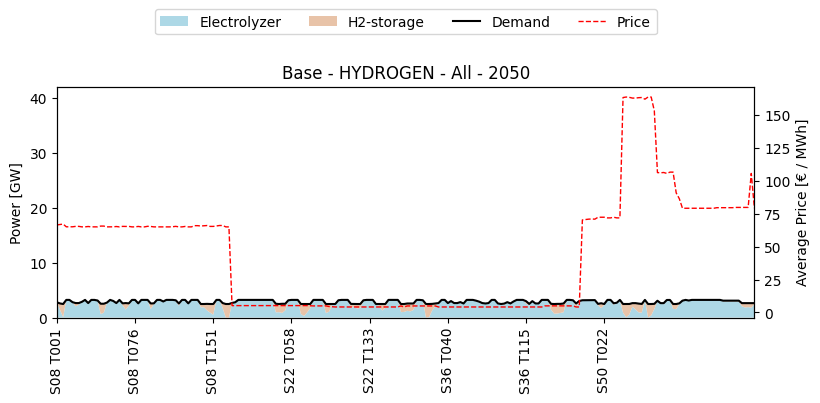

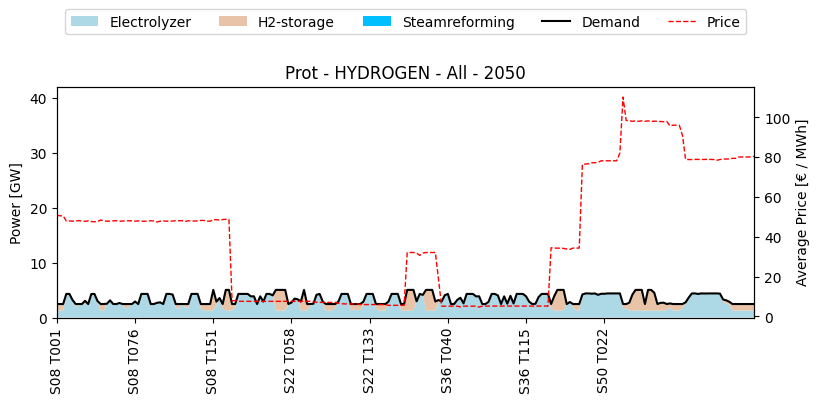

In [ ]:
fig, ax = res.plot_profile('Hydrogen', 2050, scenario='Base')
ax.set_ylim([0, 42])
fig, ax = res.plot_profile('Hydrogen', 2050, scenario='Prot')
ax.set_ylim([0, 42])